In [1]:
import uproot
import zfit
import pandas as pd
import numpy as np
import awkward as ak
import matplotlib.pyplot as plt
import mplhep as hep
import os
import joblib
import json
import warnings
from xgboost import XGBClassifier
from sklearn.model_selection import (train_test_split, GridSearchCV, StratifiedKFold, learning_curve)
from sklearn.metrics import (roc_curve, auc, precision_recall_curve, average_precision_score, confusion_matrix,
                             ConfusionMatrixDisplay, classification_report, accuracy_score, f1_score)

/home/tandrade/.local/lib/python3.9/site-packages/zfit/__init__.py:63: UserWarning: TensorFlow warnings are by default suppressed by zfit. In order to show them, set the environment variable ZFIT_DISABLE_TF_WARNINGS=0. In order to suppress the TensorFlow warnings AND this warning, set ZFIT_DISABLE_TF_WARNINGS=1.
  warnings.warn(


In [2]:
signal_path = "/home/tandrade/Flavour_Anomalies/Data/NonResonant_final_merged.root"
bg_path     = "/home/tandrade/Flavour_Anomalies/Data/Data_final_merged.root"
tree_name   = "tree_ML"

In [3]:
features = [
    'BToTrkTrkMuMu_l_xy_good',
    'BToTrkTrkMuMu_l_xy_unc_good',
    
    'BToTrkTrkMuMu_dca_good',
    'BToTrkTrkMuMu_dcaErr_good',

    'BToTrkTrkMuMu_trk1_dca_good',
    'BToTrkTrkMuMu_trk1_dcaErr_good',
    
    'BToTrkTrkMuMu_trk2_dca_good',
    'BToTrkTrkMuMu_trk2_dcaErr_good',
    
    'BToTrkTrkMuMu_fit_ditrack_mass_Kpi_good',
    'BToTrkTrkMuMu_fit_pt_good',
    'BToTrkTrkMuMu_fit_cos2D_good',
    'BToTrkTrkMuMu_svprob_good'
]

cut_features = [
    'MuMu_mass_good', 
    'BToTrkTrkMuMu_fit_mass_Kpi_good',
    'HLT_DoubleMu4_3_LowMass'
]

In [4]:
signal_file = uproot.open(signal_path)[tree_name]
background_file = uproot.open(bg_path)[tree_name]

In [5]:
cols_to_load = features + cut_features

signal_ak = signal_file.arrays(cols_to_load, library="ak")
background_ak = background_file.arrays(cols_to_load, library="ak")

In [6]:
signal_df = ak.to_dataframe(signal_ak)
background_df = ak.to_dataframe(background_ak)

In [7]:
sig_pairs = [
    ('BToTrkTrkMuMu_l_xy_good', 'BToTrkTrkMuMu_l_xy_unc_good', 'BToTrkTrkMuMu_l_xy_sig_good'),
    ('BToTrkTrkMuMu_dca_good', 'BToTrkTrkMuMu_dcaErr_good', 'BToTrkTrkMuMu_dca_sig_good'),
    ('BToTrkTrkMuMu_trk1_dca_good', 'BToTrkTrkMuMu_trk1_dcaErr_good', 'BToTrkTrkMuMu_trk1_dca_sig_good'),
    ('BToTrkTrkMuMu_trk2_dca_good', 'BToTrkTrkMuMu_trk2_dcaErr_good', 'BToTrkTrkMuMu_trk2_dca_sig_good')
]

for val, err, sig in sig_pairs:
    signal_df[sig] = signal_df[val] / signal_df[err]

for val, err, sig in sig_pairs:
    background_df[sig] = background_df[val] / background_df[err]

In [8]:
signal_df["label"] = 1
background_df["label"] = 0

In [9]:
df = pd.concat([signal_df, background_df], ignore_index=True)

cut_mass_B = (df['BToTrkTrkMuMu_fit_mass_Kpi_good'] > 5.0) & (df['BToTrkTrkMuMu_fit_mass_Kpi_good'] < 5.6)
cut_mass_MuMu = ( ((df['MuMu_mass_good'] > 1.0) & (df['MuMu_mass_good'] < 2.9)) | ((df['MuMu_mass_good'] > 4.0) & (df['MuMu_mass_good'] < 4.8)) )
cut_trigger = df['HLT_DoubleMu4_3_LowMass'] == 1

is_signal_label = (df['label'] == 1)
signal_region_cut = (df['BToTrkTrkMuMu_fit_mass_Kpi_good'] > 5.133542769) & (df['BToTrkTrkMuMu_fit_mass_Kpi_good'] < 5.416657231)
keep_signal = is_signal_label & signal_region_cut

is_bkg_label = (df['label'] == 0)
left_band = (df['BToTrkTrkMuMu_fit_mass_Kpi_good'] > 5.0) & (df['BToTrkTrkMuMu_fit_mass_Kpi_good'] <= 5.133542769)
right_band = (df['BToTrkTrkMuMu_fit_mass_Kpi_good'] >= 5.416657231) & (df['BToTrkTrkMuMu_fit_mass_Kpi_good'] < 5.6)
keep_bkg = is_bkg_label & (left_band | right_band)

final_selection_mask = (keep_signal | keep_bkg) & cut_mass_MuMu & cut_trigger
df_cut = df[final_selection_mask]

In [10]:
model = joblib.load("final_bdt_model.joblib")

In [11]:
probabilities = model.predict_proba(df_cut[features])[:, 1]
df_cut['bdt_score'] = probabilities

/tmp/ipykernel_15414/819098696.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_cut['bdt_score'] = probabilities


In [12]:
df = df_cut.copy()

Eventos esperados: 54824.93
Scale Factor: 0.0578


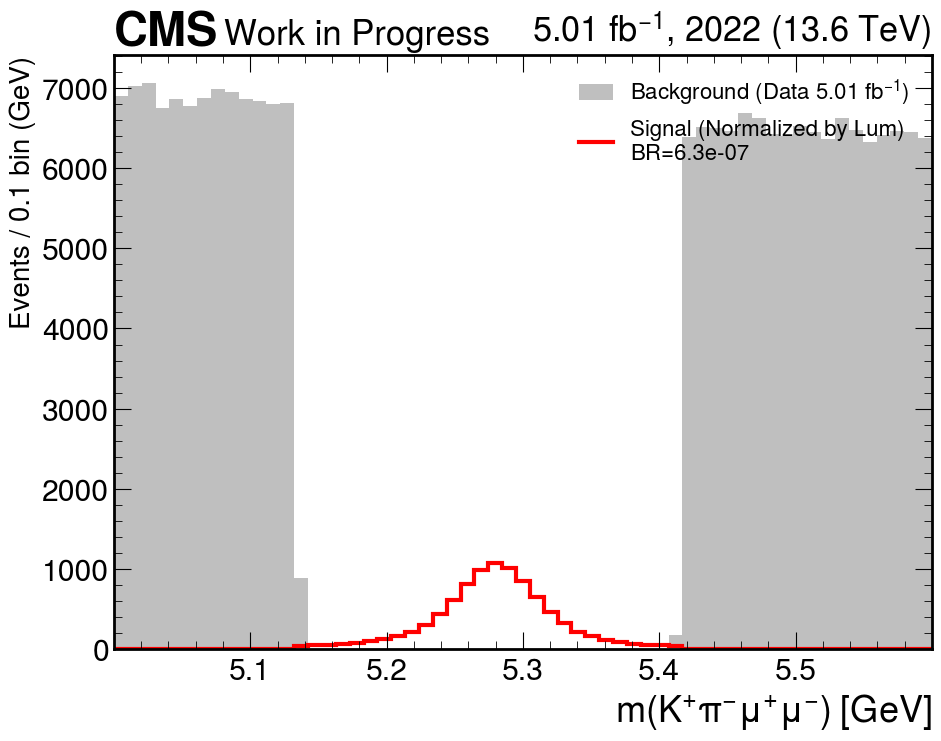

In [13]:
import matplotlib.pyplot as plt
import mplhep as hep
import numpy as np

hep.style.use(hep.style.CMS)

L_data_fb = 5.01
sigma_pb  = 17370000 
BR        = 6.30e-7
N_mc_gen  = 949314      

L_data_pb = L_data_fb * 1000 
n_expected = L_data_pb * sigma_pb * BR
scale_factor = n_expected / N_mc_gen

print(f"Eventos esperados: {n_expected:.2f}")
print(f"Scale Factor: {scale_factor:.4f}")

var_name = 'BToTrkTrkMuMu_fit_mass_Kpi_good'
corte_bdt = 0.

mask_bkg = (df['label'] == 0) & (df['bdt_score'] > corte_bdt)
data_bkg = df[mask_bkg][var_name]

mask_sig = (df['label'] == 1) & (df['bdt_score'] > corte_bdt)
data_sig = df[mask_sig][var_name]

xmin, xmax = data_bkg.min(), data_bkg.max() 
bins = np.linspace(xmin, xmax, 60)
h_bkg, _ = np.histogram(data_bkg, bins=bins)

weights_sig = np.full(len(data_sig), 
                      scale_factor)
h_sig, _ = np.histogram(data_sig, bins=bins, weights=weights_sig)
fig, ax = plt.subplots(figsize=(10, 8))

hep.histplot(
    h_bkg,
    bins=bins,
    ax=ax,
    histtype='fill',
    color='gray',
    alpha=0.5,
    edgecolor='black',
    label=f'Background (Data {L_data_fb} fb$^{{-1}}$)'
)

hep.histplot(
    h_sig,
    bins=bins,
    ax=ax,
    histtype='step',
    linewidth=3,
    color='red',
    label=f'Signal (Normalized by Lum)\nBR={BR:.1e}'
)

#ax.set_xlabel(var_name.replace('_', ' '), fontsize=20)
ax.set_xlabel(r'$m(K^{+}\pi^{-}\mu^{+}\mu^{-})\;[\mathrm{GeV}]$')
ax.set_ylabel(f"Events / 0.1 bin (GeV)", fontsize=20)
ax.set_xlim(xmin, xmax)
ax.legend(loc='upper right', fontsize=16)
texts = hep.label.exp_label(
    exp="CMS",
    label="Work in Progress",
    data=True,
    lumi=L_data_fb,
    year=2022,
    com=13.6,
    ax=ax
)
texts[1].set_fontsize(25) 

plt.tight_layout()
plt.show()

In [14]:
import zfit

In [15]:
mass_min_bkg, mass_max_bkg = 5.416657231, 5.6
mass_bkg = df.query(f"{mass_min_bkg} <= BToTrkTrkMuMu_fit_mass_Kpi_good <= {mass_max_bkg}")["BToTrkTrkMuMu_fit_mass_Kpi_good"].to_numpy()
print(f"Eventos no sideband: {len(mass_bkg)}")

Eventos no sideband: 116689


FitResult of
<UnbinnedNLL model=[<zfit.<class 'zfit.models.basic.Exponential'>  params=[tau_bkg, tau_bkg]] data=[<zfit.Data: Data obs=('BToTrkTrkMuMu_fit_mass_Kpi_good',) shape=(116689, 1)>] constraints=[]> 
with
<Minuit Minuit tol=0.001>

╒═════════╤═════════════╤══════════════════╤═════════╤══════════════════════════════╕
│  valid  │  converged  │  param at limit  │   edm   │   approx. fmin (full | opt.) │
╞═════════╪═════════════╪══════════════════╪═════════╪══════════════════════════════╡
│  True   │    True     │      False       │ 0.00019 │        -197952.20 |  9998.85 │
╘═════════╧═════════════╧══════════════════╧═════════╧══════════════════════════════╛

Parameters
name       value  (rounded)        hesse    at limit
-------  ------------------  -----------  ----------
tau_bkg          -0.0879587  +/-   0.055       False


/tmp/ipykernel_15414/3945190846.py:20: DeprecationWarning: __call__ (from zfit.util.execution) is deprecated and will be removed in a future version.
Instructions for updating:
The `run(...)` method originates from the old `tf.Session` API in TF1 and is not needed anymore. In most cases, it can simply be removed. It's current functionality converts the input to numpy, which most of the time is not needed anyways.Alternatively, use `znp.asarray(...)` to convert to zfit-friendly array (that acts nearly like numpy) or `np.asarray(...) if a numpy array is *really needed*.
  pdf_vals = zfit.run(bkg_pdf.pdf(centers))


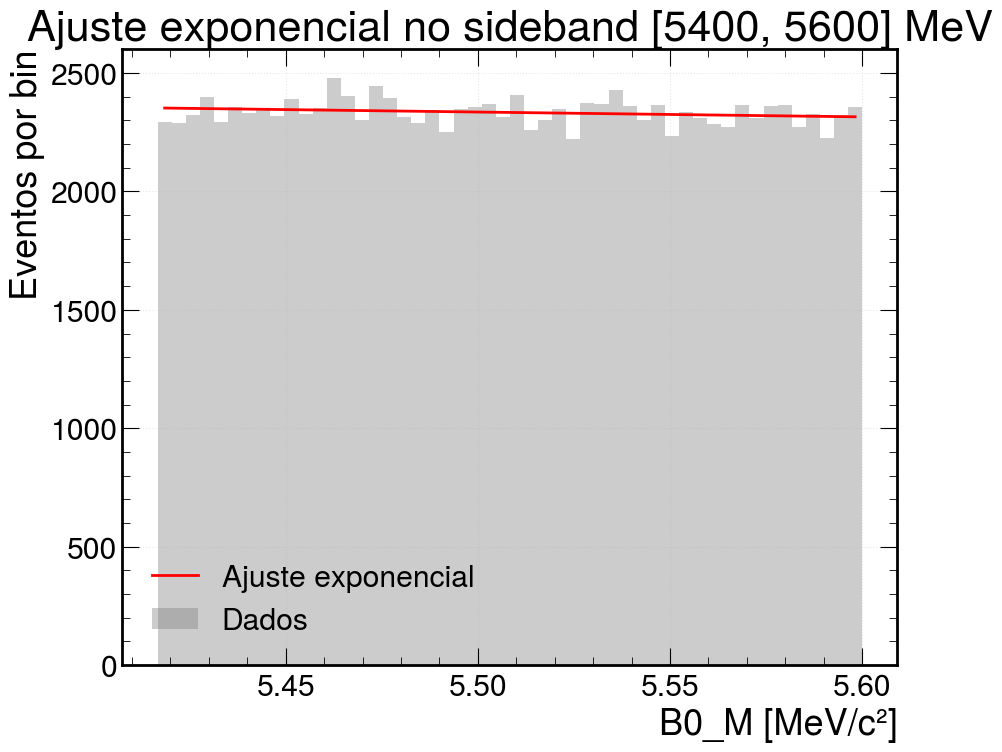

In [16]:
from zfit.loss import UnbinnedNLL

obs_bkg = zfit.Space("BToTrkTrkMuMu_fit_mass_Kpi_good", limits=(mass_min_bkg, mass_max_bkg))
tau_bkg = zfit.Parameter("tau_bkg", -0.003, -0.2, -1e-6)
bkg_pdf = zfit.pdf.Exponential(lambda_=tau_bkg, obs=obs_bkg)

data_bkg = zfit.Data.from_numpy(obs=obs_bkg, array=mass_bkg)
loss_bkg = UnbinnedNLL(model=bkg_pdf, data=data_bkg)
minim = zfit.minimize.Minuit()
result = minim.minimize(loss_bkg)
result.hesse()

print(result)

bins = 50
vals, edges = np.histogram(mass_bkg, bins=bins, range=(mass_min_bkg, mass_max_bkg))
centers = 0.5*(edges[:-1] + edges[1:])
width = edges[1] - edges[0]

pdf_vals = zfit.run(bkg_pdf.pdf(centers))
pdf_scaled = pdf_vals * len(mass_bkg) * width 

plt.figure(figsize=(10,8))
plt.bar(centers, vals, width=width, color='gray', alpha=0.4, label='Dados')
plt.plot(centers, pdf_scaled, 'r-', lw=2, label='Ajuste exponencial')
plt.xlabel("B0_M [MeV/c²]")
plt.ylabel("Eventos por bin")
plt.title("Ajuste exponencial no sideband [5400, 5600] MeV")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [17]:
mass_min_sig, mass_max_sig = 5.133542769 , 5.416657231

N_fit_bkg_simple = len(mass_bkg)


tau_val_bkg_simple = float(tau_bkg.value())

def integral_exp(lmbda, a, b):
    if abs(lmbda) < 1e-12:
        return b - a
    return (np.exp(lmbda * b) - np.exp(lmbda * a)) / lmbda

num = integral_exp(tau_val_bkg_simple, mass_min_sig, mass_max_sig)
den = integral_exp(tau_val_bkg_simple, mass_min_bkg, mass_max_bkg)
frac = num / den

B_est = N_fit_bkg_simple * frac
print(f"Background estimado em [{mass_min_sig:.5f}, {mass_max_sig:.5f}] MeV:")
print(f"N_bkg_simple = {B_est:.1f} eventos")

Background estimado em [5.13354, 5.41666] MeV:
N_bkg_simple = 183926.4 eventos


In [18]:
mass_min_bkg, mass_max_bkg = 5.133542769, 5.416657231
mass_bkg = df.query(f"{mass_min_bkg} <= BToTrkTrkMuMu_fit_mass_Kpi_good <= {mass_max_bkg}")["BToTrkTrkMuMu_fit_mass_Kpi_good"].to_numpy()
print(f"Eventos na região de sinal MC: {len(mass_bkg) * scale_factor}")

Eventos na região de sinal MC: 9218.919041117058


In [19]:
import numpy as np
import matplotlib.pyplot as plt
import zfit
from zfit.loss import UnbinnedNLL
from zfit.minimize import Minuit

In [20]:
cuts = np.linspace(0, 1, 101)

mass_min_bkg, mass_max_bkg = 5.416657231, 5.6
mass_min_sig, mass_max_sig = 5.133542769, 5.416657231

B_est_list = []
S_est_list = []
FoM_list = []

In [21]:
def integral_exp(lmbda, a, b):
    if abs(lmbda) < 1e-12:
        return b - a
    return (np.exp(lmbda * b) - np.exp(lmbda * a)) / lmbda

In [22]:
for cut_value in cuts:

    df_cut = df[df["bdt_score"] > cut_value]

    # -------------------------
    # BACKGROUND (sideband)
    # -------------------------
    mass_bkg = df_cut.query(
        f"{mass_min_bkg} <= BToTrkTrkMuMu_fit_mass_Kpi_good <= {mass_max_bkg}"
    )["BToTrkTrkMuMu_fit_mass_Kpi_good"].to_numpy()

    N_bkg_sb = len(mass_bkg)
    print(f"\nBDT > {cut_value:.2f} | Sideband: {N_bkg_sb} eventos")

    # proteção contra estatística baixa
    if N_bkg_sb < 10:
        print("Estatística insuficiente no sideband → pulando")
        B_est_list.append(0.0)
        S_est_list.append(0.0)
        FoM_list.append(0.0)
        continue

    obs_bkg = zfit.Space(
        "BToTrkTrkMuMu_fit_mass_Kpi_good",
        limits=(mass_min_bkg, mass_max_bkg)
    )

    tau_bkg = zfit.Parameter(
        f"tau_bkg_{cut_value:.2f}", -0.003, -0.2, -1e-6
    )

    bkg_pdf = zfit.pdf.Exponential(lambda_=tau_bkg, obs=obs_bkg)

    data_bkg = zfit.Data.from_numpy(obs=obs_bkg, array=mass_bkg)

    loss_bkg = UnbinnedNLL(model=bkg_pdf, data=data_bkg)
    minim = Minuit()
    result = minim.minimize(loss_bkg)
    result.hesse()

    tau_val = float(tau_bkg.value())

    # extrapolação para a região de sinal
    frac = (
        integral_exp(tau_val, mass_min_sig, mass_max_sig)
        / integral_exp(tau_val, mass_min_bkg, mass_max_bkg)
    )

    B_est = N_bkg_sb * frac
    B_est_list.append(B_est)

    print(f"B estimado na região de sinal: {B_est:.2f}")

    # -------------------------
    # SIGNAL (MC)
    # -------------------------
    mass_signal = df_cut.query(
        f"{mass_min_sig} <= BToTrkTrkMuMu_fit_mass_Kpi_good <= {mass_max_sig}"
    )["BToTrkTrkMuMu_fit_mass_Kpi_good"].to_numpy()

    S_est = len(mass_signal) * scale_factor
    S_est_list.append(S_est)

    print(f"S estimado (MC escalado): {S_est:.2f}")

    # -------------------------
    # FoM
    # -------------------------
    fom = S_est / np.sqrt(S_est + B_est) if (S_est + B_est) > 0 else 0.0
    FoM_list.append(fom)

    print(f"FoM = {fom:.3f}")


BDT > 0.00 | Sideband: 116689 eventos
B estimado na região de sinal: 183926.38
S estimado (MC escalado): 9218.92
FoM = 20.977

BDT > 0.01 | Sideband: 65865 eventos
B estimado na região de sinal: 101707.55
S estimado (MC escalado): 9208.35
FoM = 27.649

BDT > 0.02 | Sideband: 44329 eventos
B estimado na região de sinal: 68452.04
S estimado (MC escalado): 9189.35
FoM = 32.979

BDT > 0.03 | Sideband: 34184 eventos
B estimado na região de sinal: 52786.31
S estimado (MC escalado): 9168.73
FoM = 36.836

BDT > 0.04 | Sideband: 28366 eventos
B estimado na região de sinal: 43802.27
S estimado (MC escalado): 9151.18
FoM = 39.768

BDT > 0.05 | Sideband: 24411 eventos
B estimado na região de sinal: 37695.03
S estimado (MC escalado): 9134.77
FoM = 42.212

BDT > 0.06 | Sideband: 21532 eventos
B estimado na região de sinal: 33249.32
S estimado (MC escalado): 9118.66
FoM = 44.301

BDT > 0.07 | Sideband: 19410 eventos
B estimado na região de sinal: 29972.57
S estimado (MC escalado): 9102.49
FoM = 46.0

In [23]:
cuts = np.array(cuts)
FoM_list = np.array(FoM_list)

best_idx = np.argmax(FoM_list)

print("\n==============================")
print(f"Melhor threshold de BDT: {cuts[best_idx]:.2f}")
print(f"FoM máxima: {FoM_list[best_idx]:.3f}")
print(f"S = {S_est_list[best_idx]:.2f}")
print(f"B = {B_est_list[best_idx]:.2f}")
print("==============================")


Melhor threshold de BDT: 0.93
FoM máxima: 84.249
S = 7591.12
B = 527.48


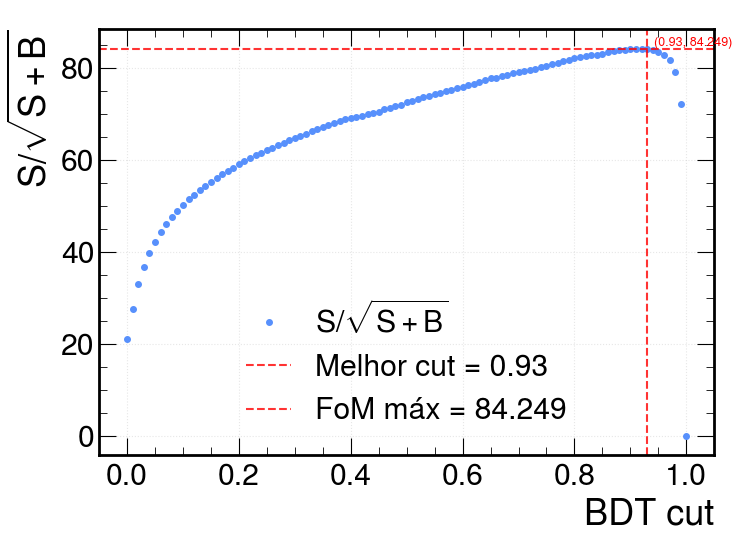

In [24]:
best_idx = np.argmax(FoM_list)
best_cut = cuts[best_idx]
best_fom = FoM_list[best_idx]

plt.figure(figsize=(8,6))
plt.plot(
    cuts,
    FoM_list,
    marker='o',
    markersize=4,
    linestyle='none',  
    label=r"$S/\sqrt{S+B}$"
)

plt.axvline(
    best_cut,
    color='red',
    linestyle='--',
    alpha=0.8,
    label=f"Melhor cut = {best_cut:.2f}"
)

plt.axhline(
    best_fom,
    color='red',
    linestyle='--',
    alpha=0.8,
    label=f"FoM máx = {best_fom:.3f}"
)

plt.text(
    best_cut,
    best_fom,
    f"  ({best_cut:.2f}, {best_fom:.3f})",
    color='red',
    fontsize=9,
    verticalalignment='bottom'
)
plt.xlabel("BDT cut")
plt.ylabel(r"$S/\sqrt{S+B}$")

plt.title(" ", fontsize=10)
plt.grid(alpha=0.3)
plt.legend(fontsize='small')
plt.tight_layout()
plt.show()